# Pneumonia Detection using Chest X-Rays

### Setup

#### Setup the Environment

run the following command
```bash
conda create -n 10701-project python=3.14.4
conda activate 10701-project
pip install -r requirements.txt
```
then, open this notebook and use this environemnt `10701-project` from the kernel selector.

#### Download Data

In [1]:
import kagglehub
kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia", output_dir="./data")
root = "./data"
print("Path to dataset files:", root)

/home/ec2-user/miniforge3/envs/10701-project/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 2.29G/2.29G [00:12<00:00, 193MB/s]

Extracting files...


Path to dataset files: ./data


In [1]:
root = "./data"

### Part 1. Logistics Regression

#### Imports

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from utils.loader import load_data
from utils.image import preprocess_image
from utils.metric import calculate_metrics, print_metrics, plot_ROC
from models.LinearModel import LinearModel
from models.PCA import PCA

#### Load Data

In [3]:
data_path = os.path.join(root, "chest_xray")
train_data, train_labels = load_data(os.path.join(data_path, "train"))
val_data, val_labels = load_data(os.path.join(data_path, "val"))
test_data, test_labels = load_data(os.path.join(data_path, "test"))

Loading NORMAL images from ./data/chest_xray/train: 100%|██████████| 1341/1341 [00:00<00:00, 2806.35it/s]
Loading PNEUMONIA images from ./data/chest_xray/train: 100%|██████████| 3875/3875 [00:00<00:00, 11292.86it/s]
Loading NORMAL images from ./data/chest_xray/val: 100%|██████████| 8/8 [00:00<00:00, 4592.09it/s]
Loading PNEUMONIA images from ./data/chest_xray/val: 100%|██████████| 8/8 [00:00<00:00, 11225.97it/s]
Loading NORMAL images from ./data/chest_xray/test: 100%|██████████| 234/234 [00:00<00:00, 13417.19it/s]
Loading PNEUMONIA images from ./data/chest_xray/test: 100%|██████████| 390/390 [00:00<00:00, 14469.77it/s]


We don't need a validation set for this task, instead we will not use validation(for logistics regression) or use cross-validation(regularized regression)

In [4]:
train_data = train_data + val_data
train_labels = train_labels + val_labels

We are almost in a $p > n$ regime...

In [5]:
print("Training data size:", len(train_data))
print("Test data size:", len(test_data))

Training data size: 5232
Test data size: 624


Example of a normal and pneumonia image

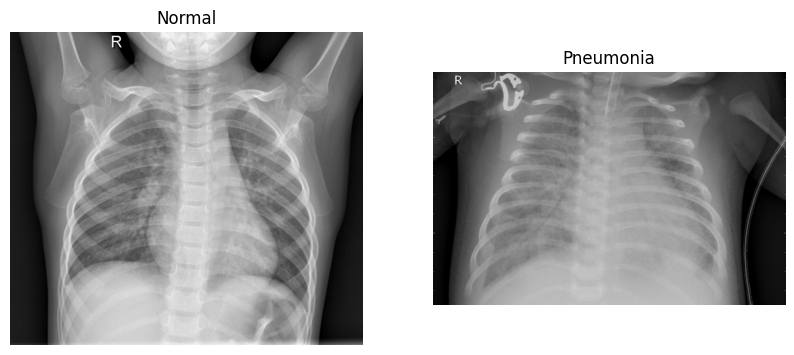

In [6]:
normal_example = train_data[train_labels.index(0)]
pneumonia_example = train_data[train_labels.index(1)]
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(normal_example, cmap="gray")
plt.title("Normal")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(pneumonia_example, cmap="gray")
plt.title("Pneumonia")
plt.axis("off")
plt.show()

#### Preprocess Images

In [7]:
train_data = [preprocess_image(img) for img in tqdm(train_data, desc="Preprocessing train images")]
test_data = [preprocess_image(img) for img in tqdm(test_data, desc="Preprocessing test images")]

Preprocessing test images: 100%|██████████| 624/624 [00:03<00:00, 161.63it/s]


Show resized image

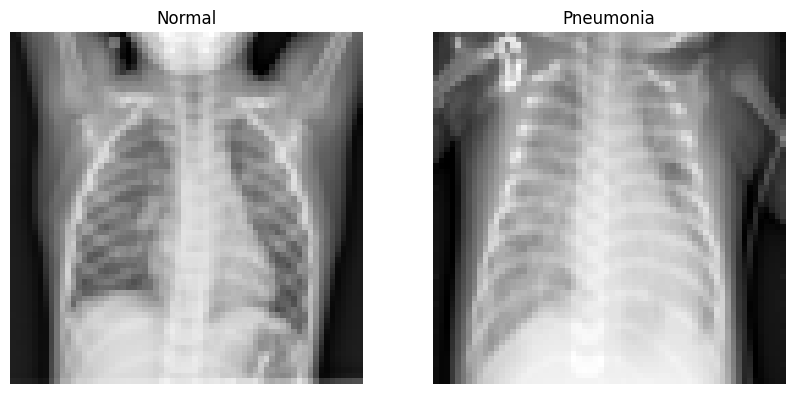

In [8]:
normal_example = train_data[train_labels.index(0)]
pneumonia_example = train_data[train_labels.index(1)]
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(normal_example.reshape(64, 64), cmap="gray")
plt.title("Normal")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(pneumonia_example.reshape(64, 64), cmap="gray")
plt.title("Pneumonia")
plt.axis("off")
plt.show()

#### Fit Logistics Regression Model

In [18]:
LR_model = LinearModel(64 * 64)
LR_model.fit(np.array(train_data), np.array(train_labels), learning_rate=0.1, num_iterations=10000)
train_preds = LR_model.predict(np.array(train_data))
test_preds = LR_model.predict(np.array(test_data))

Training Linear Model, loss:8.2337:   0%|          | 19/10000 [00:00<01:49, 91.29it/s]

Iteration 0, Loss: 8.2337


Training Linear Model, loss:0.1223:  10%|█         | 1013/10000 [00:11<01:36, 93.09it/s]

Iteration 1000, Loss: 0.1223


Training Linear Model, loss:0.1079:  20%|██        | 2010/10000 [00:22<01:26, 92.00it/s]

...

Iteration 8000, Loss: 0.0582


Training Linear Model, loss:0.0550:  90%|█████████ | 9019/10000 [01:39<00:10, 91.08it/s]

Iteration 9000, Loss: 0.0550


Training Linear Model, loss:0.0557: 100%|██████████| 10000/10000 [01:50<00:00, 90.60it/s]

Final Loss: 0.0541


This simple full-batch gradient descend is not very stable... might want to consider implementing second-order methods.

#### Evaluate Fit

In [19]:
print_metrics(np.array(train_labels), train_preds)
print_metrics(np.array(test_labels), test_preds)

Accuracy: 0.9803
Precision: 0.9864
Recall: 0.9871
F1 Score: 0.9867
Confusion Matrix:
[[1296   53]
 [  50 3833]]
Accuracy: 0.7548
Precision: 0.7223
Recall: 0.9872
F1 Score: 0.8342
Confusion Matrix:
[[ 86 148]
 [  5 385]]


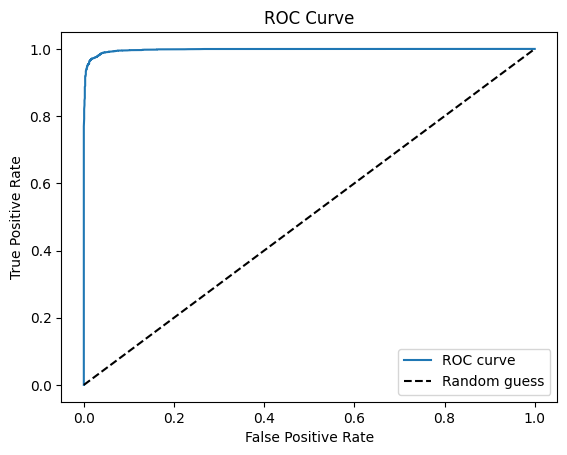

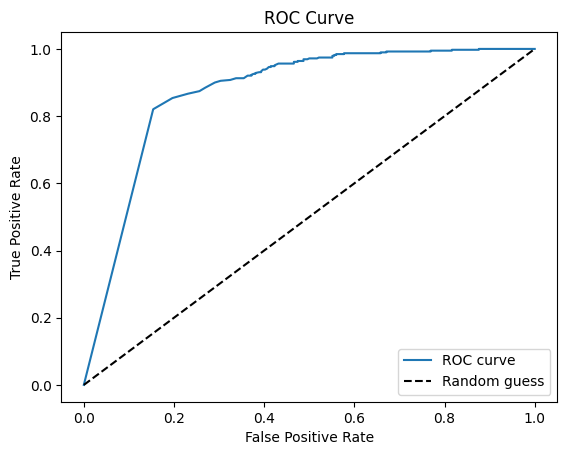

In [20]:
plot_ROC(np.array(train_labels), LR_model.prob(np.array(train_data)))
plot_ROC(np.array(test_labels), LR_model.prob(np.array(test_data)))

### Part 2. Dimensionality Reduction with PCA

In [21]:
PCA_model = PCA()
PCA_model.fit(np.array(train_data))
var_explained = PCA_model.var_explained()

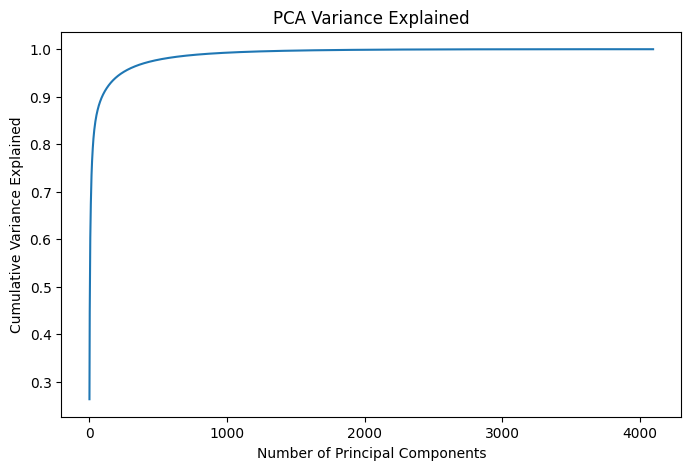

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(var_explained))
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Variance Explained")
plt.title("PCA Variance Explained")
plt.show()  

In [29]:
p = np.argmax(np.cumsum(var_explained) >= 0.9) + 1
print(f"{p} principal components explain 90% of the variance.")
PCA_model.select(p)
train_data_pca = PCA_model.transform(np.array(train_data))
test_data_pca = PCA_model.transform(np.array(test_data))


93 principal components explain 90% of the variance.


In [31]:
LR_model_PCA = LinearModel(p)
LR_model_PCA.fit(train_data_pca, np.array(train_labels), learning_rate=0.1, num_iterations=10000)
train_preds = LR_model_PCA.predict(train_data_pca)
test_preds = LR_model_PCA.predict(test_data_pca)

Training Linear Model, loss:0.1332:   3%|▎         | 279/10000 [00:00<00:03, 2585.10it/s]

Iteration 0, Loss: 0.6301


Training Linear Model, loss:0.1080:  18%|█▊        | 1778/10000 [00:00<00:02, 3037.62it/s]

Iteration 1000, Loss: 0.1146


Training Linear Model, loss:0.1030:  28%|██▊       | 2761/10000 [00:00<00:01, 4003.79it/s]

...

Iteration 6000, Loss: 0.0999
Iteration 7000, Loss: 0.0995


Training Linear Model, loss:0.0989:  94%|█████████▎| 9372/10000 [00:01<00:00, 7138.62it/s]

Iteration 8000, Loss: 0.0992
Iteration 9000, Loss: 0.0990


Training Linear Model, loss:0.0989: 100%|██████████| 10000/10000 [00:01<00:00, 5212.83it/s]

Final Loss: 0.0989


In [32]:
print_metrics(np.array(train_labels), train_preds)
print_metrics(np.array(test_labels), test_preds)

Accuracy: 0.9629
Precision: 0.9728
Recall: 0.9773
F1 Score: 0.9751
Confusion Matrix:
[[1243  106]
 [  88 3795]]
Accuracy: 0.7516
Precision: 0.7205
Recall: 0.9846
F1 Score: 0.8321
Confusion Matrix:
[[ 85 149]
 [  6 384]]


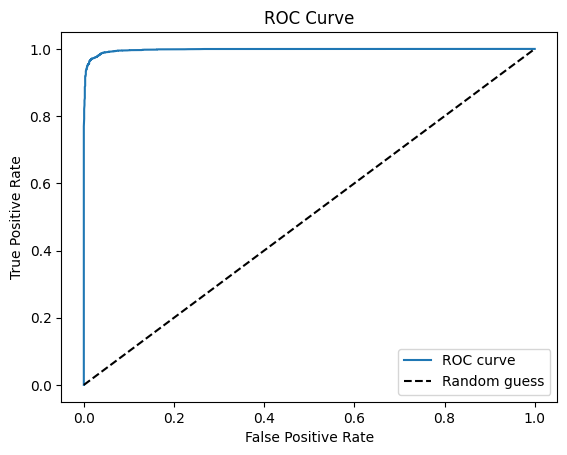

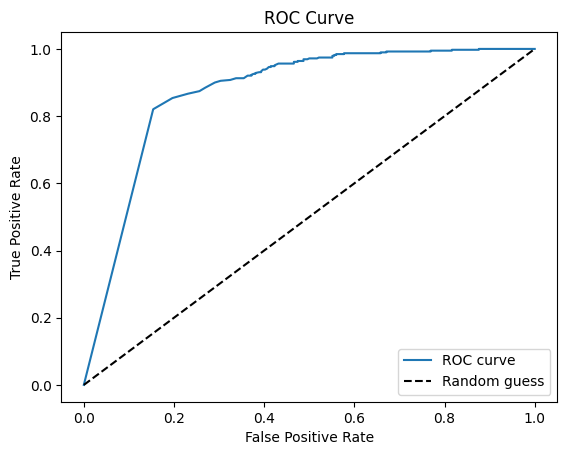

In [33]:
plot_ROC(np.array(train_labels), LR_model.prob(np.array(train_data)))
plot_ROC(np.array(test_labels), LR_model.prob(np.array(test_data)))

The result is identical to logistics regression on all pixels.